# Chest classifier build — KAD-512, one endpoint at a time

This is the current Colab workflow. It evaluates the pinned KAD-512 candidate on Google's radiologist-adjudicated **NIH development** labels. It does **not** run the locked NIH test cohort and does not make a clinical-use claim.

What to do:

1. Connect this notebook to any available GPU runtime (T4, L4, A100, etc.) — the exact accelerator is recorded in every result's runtime contract, so evidence stays traceable per-accelerator without forcing one GPU class.
2. If the GitHub repository is private, add a Colab secret named `GITHUB_TOKEN` with read access. Do not paste a token into a cell.
3. Optionally add a Colab secret named `HF_TOKEN` with read access to reduce public Hugging Face rate-limit waits. Anonymous fetching remains resumable.
4. Choose one `ACTIVE_TARGET` below, beginning with `Pneumothorax`.
5. Select **Run all**. Durable inputs and results are saved under Google Drive → `MyDrive/doctor_assistant/kad_phase1`.

Each `ACTIVE_TARGET` is a separate one-query model identity with its own cached query pack, predictions, calibration, and decision artifact. Do not reuse or slice results from the retired three-query phase-1 pack: KAD decoder self-attention makes every query score depend on the other queries present. If verified multi-source original-pixel evidence is present at Drive path `data/nih_original_development` (see `scripts/fetch_nih_original_images.py`), this notebook uses it and attempts acceptance-eligible scoring; otherwise it falls back to the 320-pixel image mirror for development candidate selection only. Either way, a completed decision artifact and a frozen lock are required before any test run.

In [1]:
from pathlib import Path

REPO_URL = "https://github.com/Hamza09Hamza/doctor_assistant.git"
REPO_REF = "classifier-evaluation-colab"
REPO_DIR = Path("/content/doctor_assistant")
DRIVE_ROOT = Path("/content/drive/MyDrive/doctor_assistant/kad_phase1")

ACTIVE_TARGET = "Airspace_opacity"  # then Nodule_or_mass; then Airspace_opacity
BATCH_SIZE = 16
BOOTSTRAP_SAMPLES = 1000
RANDOM_SEED = 42
PATIENT_PARTITION_SEED = 20250729
PATIENT_SPLIT_ATTEMPTS = 512
RUN_CALIBRATION = True

ALLOWED_TARGETS = ("Pneumothorax", "Nodule_or_mass", "Airspace_opacity")
if ACTIVE_TARGET not in ALLOWED_TARGETS:
    raise ValueError(f"ACTIVE_TARGET must be one of {ALLOWED_TARGETS}")
print(f"Endpoint under decision: {ACTIVE_TARGET}")
print("Cohort: development only (locked test is disabled)")

Endpoint under decision: Airspace_opacity
Cohort: development only (locked test is disabled)


## 1. Mount Drive and load the exact branch

The clone helper keeps authentication out of the repository URL and sanitizes failures. An existing non-clean Colab clone is rejected so a rerun cannot silently mix code versions.

In [2]:
import base64
import os
import shlex
import subprocess

from google.colab import drive, userdata

drive.mount("/content/drive")

try:
    github_token = userdata.get("GITHUB_TOKEN")
except Exception:
    github_token = None

try:
    hf_token = userdata.get("HF_TOKEN")
except Exception:
    hf_token = None
if hf_token:
    os.environ["HF_TOKEN"] = hf_token

auth_header = None
if github_token:
    encoded = base64.b64encode(f"x-access-token:{github_token}".encode()).decode()
    auth_header = f"AUTHORIZATION: basic {encoded}"

def run_git(label, arguments, *, authenticated=False):
    command = ["git"]
    if authenticated and auth_header:
        command += ["-c", f"http.extraHeader={auth_header}"]
    command += [str(value) for value in arguments]
    completed = subprocess.run(command, text=True, capture_output=True)
    if completed.returncode:
        detail = (completed.stderr or completed.stdout or "unknown git error").strip()
        if github_token:
            detail = detail.replace(github_token, "***")
        if auth_header:
            detail = detail.replace(auth_header, "***")
        raise RuntimeError(f"{label} failed: {detail}")
    return completed.stdout.strip()

if REPO_DIR.exists():
    if not (REPO_DIR / ".git").is_dir():
        raise RuntimeError(f"{REPO_DIR} exists but is not a Git clone; use a fresh runtime")
    origin = run_git("origin lookup", ["-C", REPO_DIR, "remote", "get-url", "origin"])
    if origin != REPO_URL:
        raise RuntimeError(f"Refusing to authenticate to unexpected origin {origin!r}; use a fresh runtime")
    dirty = run_git("repository status", ["-C", REPO_DIR, "status", "--porcelain"])
    if dirty:
        raise RuntimeError("The Colab clone has local changes. Use a fresh runtime rather than mixing versions.")
    run_git("branch fetch", ["-C", REPO_DIR, "fetch", "--depth", "1", "origin", REPO_REF], authenticated=True)
    run_git("branch checkout", ["-C", REPO_DIR, "checkout", "--detach", "FETCH_HEAD"])
else:
    run_git(
        "repository clone",
        ["clone", "--branch", REPO_REF, "--single-branch", "--depth", "1", REPO_URL, REPO_DIR],
        authenticated=True,
    )

GIT_SHA = run_git("commit lookup", ["-C", REPO_DIR, "rev-parse", "HEAD"])
os.chdir(REPO_DIR)
DRIVE_ROOT.mkdir(parents=True, exist_ok=True)
print(f"Loaded {REPO_REF} at {GIT_SHA}")

Mounted at /content/drive
Loaded classifier-evaluation-colab at 818b5f7e9ee6c62050237a825bd0a96f043a2cd8


## 2. Install the focused runtime and run software checks

A passing test suite proves the evaluation contracts are wired correctly; it is not a performance result.

In [3]:
%pip install -q "transformers==5.12.1" "numpy==2.0.2" "scipy==1.18.0" "scikit-learn==1.9.0" "pandas==2.2.2" "Pillow==12.3.0" "datasets>=2.18,<5" "huggingface_hub>=0.23" "pyarrow>=15,<24" "matplotlib>=3.8" "gdown>=5" "timm>=0.9" "monai>=1.3" "pydicom>=2.4" "nibabel>=5.2" "PyYAML>=6" "pydantic>=2.6"


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.3/62.3 kB 5.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.2/11.2 MB 74.9 MB/s eta 0:00:00:00:010:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 35.3/35.3 MB 30.2 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 88.4 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 69.7 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 63.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 76.1 MB/s eta 0:00:00


In [4]:
import sys
import torch

def run_step(arguments):
    command = [str(value) for value in arguments]
    print("$", shlex.join(command))
    subprocess.run(command, cwd=REPO_DIR, check=True)

if not torch.cuda.is_available():
    raise RuntimeError("No GPU is attached. Select any available GPU runtime, reconnect, then Run all.")
GPU_NAME = torch.cuda.get_device_name(0)
# No fixed accelerator lock: scripts/benchmark_kad.py independently records the exact
# GPU name, compute capability, and CUDA/cuDNN runtime into every result's environment
# block (see _hardware_contract()), so evidence stays traceable and segregable by
# accelerator without needing to force every Colab run onto one GPU class. This used to
# hard-require a T4; changed so whatever Colab actually assigns (T4/L4/A100/...) is used
# directly, and disambiguation happens downstream in the recorded runtime contract instead.
print("GPU:", GPU_NAME)
run_step([sys.executable, "-m", "unittest", "discover", "-s", "tests", "-p", "test_*.py"])


GPU: Tesla T4
$ /usr/bin/python3 -m unittest discover -s tests -p 'test_*.py'


## 3. Verify the official KAD checkpoint and build the lean query pack

The official 1.99 GB checkpoint is downloaded only when this endpoint's smaller one-query pack is not already cached. The source checkpoint is accepted only at its pinned byte size and SHA-256. Phase-1 export reads the reviewed singleton embedding from the repository's checksum-pinned feature asset rather than recomputing Med-KEBERT output across runtimes. Normal GPU inference then uses the BERT-free singleton pack. Its endpoint label, prompt, query-set ID, checkpoint identity, canonicalization contract, and semantic tensor hash must all match the reviewed endpoint contract. The old shared three-query and format-v2 caches have different model identities and are deliberately ignored.

In [5]:
import hashlib
import shutil
import uuid

import gdown

KAD_DRIVE_FILE_ID = "1nPPs-jWp5gNR5QjXgbnwFNUGygbC3vKI"
KAD_CHECKPOINT_BYTES = 1_990_875_399
KAD_CHECKPOINT_SHA256 = "eb7223657220aa51eef43b2e155fd73c593eb5821fdcc8741782f6581ddfea76"

from scripts.benchmark_kad import inspect_query_pack
from scripts.export_kad_query_pack import PHASE1_QUERY_SPECS

QUERY_SPEC = PHASE1_QUERY_SPECS[ACTIVE_TARGET]
QUERY_PROMPT = QUERY_SPEC["prompt"]
QUERY_SET_ID = QUERY_SPEC["query_set"]
KAD_QUERY_PACK_SEMANTIC_SHA256 = QUERY_SPEC["semantic_sha256"]
TARGET_SLUG = ACTIVE_TARGET.lower()
QUERY_PACK_FILENAME = f"kad-512-phase1-{TARGET_SLUG}-single-query-v3-pil.pt"

MODEL_DIR = DRIVE_ROOT / "models"
MODEL_DIR.mkdir(parents=True, exist_ok=True)
DRIVE_CHECKPOINT = MODEL_DIR / "kad-512-official.pt"
DRIVE_QUERY_PACK = MODEL_DIR / QUERY_PACK_FILENAME
LOCAL_CHECKPOINT = Path("/content/kad-512-official.pt")
LOCAL_QUERY_PACK = Path("/content") / QUERY_PACK_FILENAME

def sha256_file(path, chunk_size=8 * 1024 * 1024):
    digest = hashlib.sha256()
    with Path(path).open("rb") as handle:
        for chunk in iter(lambda: handle.read(chunk_size), b""):
            digest.update(chunk)
    return digest.hexdigest()

def verify_checkpoint(path):
    path = Path(path)
    if path.stat().st_size != KAD_CHECKPOINT_BYTES:
        raise RuntimeError(f"KAD checkpoint has the wrong size: {path}")
    actual = sha256_file(path)
    if actual != KAD_CHECKPOINT_SHA256:
        raise RuntimeError(f"KAD checkpoint hash mismatch: {path}")

def verify_query_pack(path):
    info = inspect_query_pack(
        path,
        expected_labels=(ACTIVE_TARGET,),
        expected_prompts=(QUERY_PROMPT,),
        expected_query_set=QUERY_SET_ID,
        expected_semantic_sha256=KAD_QUERY_PACK_SEMANTIC_SHA256,
    )
    if info["labels"] != [ACTIVE_TARGET] or info["prompts"] != [QUERY_PROMPT]:
        raise RuntimeError("The query pack is not endpoint-isolated")
    if info["source"].get("checkpoint_sha256") != KAD_CHECKPOINT_SHA256:
        raise RuntimeError("The query pack is not bound to the pinned KAD checkpoint")
    return info

def quarantine_invalid(path, label):
    path = Path(path)
    quarantined = path.with_name(f"{path.name}.invalid-{uuid.uuid4().hex}")
    os.replace(path, quarantined)
    print(f"Quarantined invalid {label}: {quarantined}")

def cached_file_is_valid(path, verifier, label):
    path = Path(path)
    if not path.exists():
        return False
    try:
        verifier(path)
        return True
    except Exception as exc:
        print(f"Cached {label} failed verification: {type(exc).__name__}: {exc}")
        quarantine_invalid(path, label)
        return False

def atomic_verified_copy(source, destination, verifier):
    source = Path(source)
    destination = Path(destination)
    if destination.exists():
        raise FileExistsError(f"Refusing to replace an existing cache file: {destination}")
    temporary = destination.with_name(f".{destination.name}.{uuid.uuid4().hex}.tmp")
    try:
        shutil.copy2(source, temporary)
        verifier(temporary)
        os.replace(temporary, destination)
        verifier(destination)
    finally:
        temporary.unlink(missing_ok=True)

if not cached_file_is_valid(DRIVE_QUERY_PACK, verify_query_pack, "query pack"):
    checkpoint_for_export = None
    if not cached_file_is_valid(DRIVE_CHECKPOINT, verify_checkpoint, "checkpoint"):
        temporary = Path("/content") / f"kad-512-{uuid.uuid4().hex}.download"
        downloaded = gdown.download(id=KAD_DRIVE_FILE_ID, output=str(temporary), quiet=False)
        if not downloaded:
            temporary.unlink(missing_ok=True)
            raise RuntimeError("The official KAD checkpoint download did not complete")
        try:
            verify_checkpoint(temporary)
            atomic_verified_copy(temporary, DRIVE_CHECKPOINT, verify_checkpoint)
        except Exception:
            temporary.unlink(missing_ok=True)
            raise
        checkpoint_for_export = temporary
    else:
        if not cached_file_is_valid(LOCAL_CHECKPOINT, verify_checkpoint, "local checkpoint"):
            atomic_verified_copy(DRIVE_CHECKPOINT, LOCAL_CHECKPOINT, verify_checkpoint)
        checkpoint_for_export = LOCAL_CHECKPOINT
    temporary_pack = Path("/content") / f"kad-phase1-{TARGET_SLUG}-{uuid.uuid4().hex}.pt"
    try:
        run_step([
            sys.executable, "scripts/export_kad_query_pack.py",
            "--checkpoint", checkpoint_for_export,
            "--output", temporary_pack,
            "--query-set", "phase1",
            "--active-target", ACTIVE_TARGET,
            "--device", "cpu",
        ])
        verify_query_pack(temporary_pack)
        atomic_verified_copy(temporary_pack, DRIVE_QUERY_PACK, verify_query_pack)
    finally:
        temporary_pack.unlink(missing_ok=True)
        checkpoint_for_export.unlink(missing_ok=True)

local_temporary = LOCAL_QUERY_PACK.with_name(f".{LOCAL_QUERY_PACK.name}.{uuid.uuid4().hex}.tmp")
try:
    shutil.copy2(DRIVE_QUERY_PACK, local_temporary)
    verify_query_pack(local_temporary)
    os.replace(local_temporary, LOCAL_QUERY_PACK)
finally:
    local_temporary.unlink(missing_ok=True)

query_info = verify_query_pack(LOCAL_QUERY_PACK)
print("Query pack SHA-256:", query_info["sha256"])
print("Query-pack semantic SHA-256:", query_info["semantic_sha256"])
print("Endpoint query:", list(zip(query_info["labels"], query_info["prompts"])))

$ /usr/bin/python3 scripts/export_kad_query_pack.py --checkpoint /content/kad-512-official.pt --output /content/kad-phase1-airspace_opacity-8629d8e732f043ceb772667aaa033c8f.pt --query-set phase1 --active-target Airspace_opacity --device cpu
Query pack SHA-256: 1cf622ba8994406e3cc5d3c250521d7b1b30317588dd8fbe4acc295349a0ecbc
Query-pack semantic SHA-256: b663a14cec6e4ce37829cecedbb6ed0ea406b64ff7c4cfcc5f35b39fff31ed5f
Endpoint query: [('Airspace_opacity', 'airspace opacity')]


## 4. Fetch and reconcile the expert-labelled development cohort

This downloads only small, byte-pinned metadata first, then builds the canonical manifest. If a verified, multi-source original-pixel evidence set is already present under Drive at `data/nih_original_development` (schema-2 `ORIGINAL_NIH_PIXELS.provenance.json`, `original_nih_pixels=true`), it is used directly and is acceptance-eligible. Otherwise this falls back to retrieving the 2,414 filename-matched development images from the pinned 320×320 mirror, which remains diagnostic-only. Downloads are resumable and automatically wait through Hugging Face rate-limit windows; an optional `HF_TOKEN` Colab secret raises the public-service limit. The two-row difference from Google's documentation is recorded and must be resolved before any locked test.

In [6]:
# The combined public source contains test labels, so it stays only in the
# ephemeral runtime. Drive receives the development-only canonical manifest.
METADATA_DIR = Path("/content/nih_metadata_pinned")
MANIFEST_DIR = DRIVE_ROOT / "data" / "expert_manifest"
DRIVE_IMAGE_ROOT = DRIVE_ROOT / "data" / "nih_expert_development_320"
DRIVE_ORIGINAL_IMAGE_ROOT = DRIVE_ROOT / "data" / "nih_original_development"
METADATA_DIR.mkdir(parents=True, exist_ok=True)
MANIFEST_DIR.mkdir(parents=True, exist_ok=True)

# Verified multi-source original-pixel evidence (schema-2) is acceptance-eligible; the
# 320px mirror below is retrieved only as a fallback and stays diagnostic-only.
USE_ORIGINAL_NIH_PIXELS = (
    DRIVE_ORIGINAL_IMAGE_ROOT / "ORIGINAL_NIH_PIXELS.provenance.json"
).is_file()
print(
    "Original-pixel evidence found at" if USE_ORIGINAL_NIH_PIXELS
    else "No original-pixel evidence found; falling back to 320px mirror at",
    DRIVE_ORIGINAL_IMAGE_ROOT if USE_ORIGINAL_NIH_PIXELS else DRIVE_IMAGE_ROOT,
)

run_step([
    sys.executable, "scripts/fetch_nih_metadata.py",
    "--output-dir", METADATA_DIR,
])

CANONICAL_MANIFEST = MANIFEST_DIR / "nih_expert_labels.csv"
CANONICAL_METADATA = MANIFEST_DIR / "nih_expert_labels.metadata.json"
run_step([
    sys.executable, "scripts/prepare_nih_expert_manifest.py",
    "--combined-csv", METADATA_DIR / "google2019_nih-chest-xray-labels.csv.gz",
    "--official-train-val-list", METADATA_DIR / "train_val_list.txt",
    "--official-test-list", METADATA_DIR / "test_list.txt",
    "--output-csv", CANONICAL_MANIFEST,
    "--output-json", CANONICAL_METADATA,
    "--output-cohort", "development",
])

if not USE_ORIGINAL_NIH_PIXELS:
    run_step([
        sys.executable, "scripts/fetch_nih_expert_images.py",
        "--manifest", CANONICAL_MANIFEST,
        "--output-images-dir", DRIVE_IMAGE_ROOT,
        "--cohort", "development",
        "--workers", "8",
    ])

Original-pixel evidence found at /content/drive/MyDrive/doctor_assistant/kad_phase1/data/nih_original_development
$ /usr/bin/python3 scripts/fetch_nih_metadata.py --output-dir /content/nih_metadata_pinned
$ /usr/bin/python3 scripts/prepare_nih_expert_manifest.py --combined-csv /content/nih_metadata_pinned/google2019_nih-chest-xray-labels.csv.gz --official-train-val-list /content/nih_metadata_pinned/train_val_list.txt --official-test-list /content/nih_metadata_pinned/test_list.txt --output-csv /content/drive/MyDrive/doctor_assistant/kad_phase1/data/expert_manifest/nih_expert_labels.csv --output-json /content/drive/MyDrive/doctor_assistant/kad_phase1/data/expert_manifest/nih_expert_labels.metadata.json --output-cohort development


## 4a. Optional: bring in verified original-pixel NIH sources

Skip this cell entirely on a first pass — the notebook falls back to the 320px development mirror automatically (diagnostic-only candidate ranking, no acceptance-eligible scoring). Come back to this once you have **two or more independently-operated, already-downloaded and extracted** copies of the official NIH ChestX-ray14 release sitting somewhere Colab can read them (local `/content/...` paths, or mounted Drive paths — not URLs: `scripts/fetch_nih_original_images.py` never downloads anything itself, since no NIH-published per-file checksum manifest exists to verify a single download against). One documented, pinned option for one of the two sources is the NIH-attributed academictorrents release, infohash `557481faacd824c83fbf57dcf7b6da9383b3235a` — fetch it with whatever torrent client you have available in this Colab session (not included here: which client is available/permitted varies by environment, so this notebook doesn't assume one). You are responsible for sourcing a second, independently-operated copy yourself (e.g. a direct download from the NIH Clinical Center's own release) — this notebook cannot recommend a second URL because none is pinned anywhere in this repo and guessing one here would be worse than leaving it to you to confirm.

Once both source directories exist and each is a flat directory of canonical `00000001_000.png`-style filenames, fill in `ORIGINAL_PIXEL_SOURCES` below (`"name": "/path/to/directory"`, at least two entries) and run this cell. It writes verified pixels straight to `DRIVE_ORIGINAL_IMAGE_ROOT` (Drive-durable), and the very next cell picks up `USE_ORIGINAL_NIH_PIXELS` automatically — no other cell needs editing.

In [7]:
# Fill in at least two independently-operated source directories, e.g.:
# ORIGINAL_PIXEL_SOURCES = {
#     "academictorrents (infohash 557481faacd824c83fbf57dcf7b6da9383b3235a)": "/content/nih_torrent",
#     "NIH Clinical Center direct release": "/content/nih_direct",
# }
ORIGINAL_PIXEL_SOURCES: dict[str, str] = {}

if ORIGINAL_PIXEL_SOURCES:
    if len(ORIGINAL_PIXEL_SOURCES) < 2:
        raise ValueError(
            "ORIGINAL_PIXEL_SOURCES needs at least two independently-operated "
            "sources; fetch_nih_original_images.py refuses to run on just one."
        )
    DRIVE_ORIGINAL_IMAGE_ROOT.mkdir(parents=True, exist_ok=True)
    source_args = []
    for name, source_path in ORIGINAL_PIXEL_SOURCES.items():
        source_args += ["--source", f"{name}={source_path}"]
    run_step([
        sys.executable, "scripts/fetch_nih_original_images.py",
        "--manifest", CANONICAL_MANIFEST,
        "--output-images-dir", DRIVE_ORIGINAL_IMAGE_ROOT,
        "--cohort", "development",
        *source_args,
    ])
    # Recompute — the flag was already set (False) by the previous cell before this
    # ingestion ran; downstream cells read USE_ORIGINAL_NIH_PIXELS, not the sources
    # dict, so this must be refreshed here for the rest of the notebook to see it.
    USE_ORIGINAL_NIH_PIXELS = (
        DRIVE_ORIGINAL_IMAGE_ROOT / "ORIGINAL_NIH_PIXELS.provenance.json"
    ).is_file()
    print("Original-pixel ingestion complete. USE_ORIGINAL_NIH_PIXELS =", USE_ORIGINAL_NIH_PIXELS)
else:
    print("ORIGINAL_PIXEL_SOURCES is empty — skipping ingestion, using existing fallback logic.")


ORIGINAL_PIXEL_SOURCES is empty — skipping ingestion, using existing fallback logic.


In [8]:
import json

if USE_ORIGINAL_NIH_PIXELS:
    LOCAL_IMAGE_ROOT = Path("/content/nih_original_development")
    SOURCE_IMAGE_ROOT = DRIVE_ORIGINAL_IMAGE_ROOT
    PROVENANCE_FILENAME = "ORIGINAL_NIH_PIXELS.provenance.json"
else:
    LOCAL_IMAGE_ROOT = Path("/content/nih_expert_development_320")
    SOURCE_IMAGE_ROOT = DRIVE_IMAGE_ROOT
    PROVENANCE_FILENAME = "DEVELOPMENT_ONLY.provenance.json"

LOCAL_IMAGE_ROOT.mkdir(parents=True, exist_ok=True)
image_provenance = json.loads((SOURCE_IMAGE_ROOT / PROVENANCE_FILENAME).read_text())
if USE_ORIGINAL_NIH_PIXELS:
    if image_provenance.get("schema_version") != 2 or image_provenance.get("original_nih_pixels") is not True:
        raise RuntimeError("Original-pixel evidence is not a verified schema-2 original_nih_pixels=true record")
else:
    if image_provenance.get("original_nih_pixels") is not False:
        raise RuntimeError("Development mirror provenance did not fail closed")

for index, record in enumerate(image_provenance["images"], start=1):
    filename = record["filename"]
    source = SOURCE_IMAGE_ROOT / filename
    destination = LOCAL_IMAGE_ROOT / filename
    expected_hash = record["output_sha256"]
    if not destination.is_file() or sha256_file(destination) != expected_hash:
        shutil.copy2(source, destination)
    if sha256_file(destination) != expected_hash:
        raise RuntimeError(f"Local image copy failed verification: {filename}")
    if index % 500 == 0 or index == len(image_provenance["images"]):
        print(f"Local verified copies: {index:,}/{len(image_provenance['images']):,}")

LOCAL_IMAGE_PROVENANCE = LOCAL_IMAGE_ROOT / PROVENANCE_FILENAME
shutil.copy2(SOURCE_IMAGE_ROOT / PROVENANCE_FILENAME, LOCAL_IMAGE_PROVENANCE)
print(
    "Original NIH images are local; inference will not read them through Drive FUSE."
    if USE_ORIGINAL_NIH_PIXELS else
    "Development mirror images are local; inference will not read them through Drive FUSE."
)

Local verified copies: 500/2,414
Local verified copies: 1,000/2,414
Local verified copies: 1,500/2,414
Local verified copies: 2,000/2,414
Local verified copies: 2,414/2,414
Original NIH images are local; inference will not read them through Drive FUSE.


## 5. Run the real expert-development benchmark

The benchmark requires a clean Git worktree; verifies pinned source metadata, official manifest membership, image dimensions and hashes, this endpoint's singleton query-set and semantic identity, prompt identity, and code/runtime versions; and records deterministic inference controls. It writes exactly one score column for `ACTIVE_TARGET` and deliberately defers AUROC/AUPRC until the next cell freezes patient roles.

In [9]:
from datetime import datetime, timezone

PATIENT_ROLE_FRACTIONS = {
    "model_selection": 0.30,
    "calibration": 0.20,
    "threshold_selection": 0.20,
    "acceptance": 0.30,
}
RUN_CONFIG = {
    "active_target": ACTIVE_TARGET,
    "batch_size": BATCH_SIZE,
    "bootstrap_samples": BOOTSTRAP_SAMPLES,
    "inference_seed": RANDOM_SEED,
    "patient_partition_seed": PATIENT_PARTITION_SEED,
    "patient_split_attempts": PATIENT_SPLIT_ATTEMPTS,
    "sensitivity_target": 0.85,
    "specificity_floor": 0.60,
    "minimum_calibration_positives": 10,
    "minimum_calibration_negatives": 20,
    "minimum_threshold_positives": 10,
    "minimum_threshold_negatives": 20,
    "minimum_acceptance_positive_patients": 22,
    "minimum_acceptance_negative_patients": 20,
    "acceptance_interval": "two_sided_95pct_wilson_on_score_blind_sha256_selected_studies",
    "original_nih_pixels": USE_ORIGINAL_NIH_PIXELS,
    "acceptance_eligible": USE_ORIGINAL_NIH_PIXELS,
    "patient_role_fractions": PATIENT_ROLE_FRACTIONS,
    "query_mode": "endpoint_isolated_single_query",
    "query_count": 1,
    "query_set_id": QUERY_SET_ID,
    "query_pack_sha256": query_info["sha256"],
    "query_pack_semantic_sha256": KAD_QUERY_PACK_SEMANTIC_SHA256,
}
config_bytes = json.dumps(RUN_CONFIG, sort_keys=True, separators=(",", ":")).encode()
CONFIG_SHA256 = hashlib.sha256(config_bytes).hexdigest()
UTC_RUN_TIMESTAMP = datetime.now(timezone.utc).strftime("%Y%m%dT%H%M%S%fZ")
RUN_ID = f"{ACTIVE_TARGET.lower()}-{GIT_SHA[:12]}-{CONFIG_SHA256[:12]}-{UTC_RUN_TIMESTAMP}"
RESULT_DIR = DRIVE_ROOT / "results" / RUN_ID
RESULT_DIR.mkdir(parents=True, exist_ok=False)
DEVELOPMENT_RESULT = RESULT_DIR / "kad_phase1_development.json"

run_step([
    sys.executable, "scripts/benchmark_kad.py",
    "--query-pack", LOCAL_QUERY_PACK,
    "--manifest", CANONICAL_MANIFEST,
    "--manifest-metadata", CANONICAL_METADATA,
    "--source-metadata-provenance", METADATA_DIR / "nih_metadata.provenance.json",
    "--image-root", LOCAL_IMAGE_ROOT,
    "--image-provenance", LOCAL_IMAGE_PROVENANCE,
    "--official-train-val-manifest", METADATA_DIR / "train_val_list.txt",
    "--official-test-manifest", METADATA_DIR / "test_list.txt",
    "--cohort", "development",
    "--defer-development-ranking",
    "--active-target", ACTIVE_TARGET,
    "--device", "cuda",
    "--batch-size", str(BATCH_SIZE),
    "--bootstrap-samples", str(BOOTSTRAP_SAMPLES),
    "--seed", str(RANDOM_SEED),
    "--output", DEVELOPMENT_RESULT,
])
DEVELOPMENT_PREDICTIONS = DEVELOPMENT_RESULT.with_suffix(".predictions.npz")
print("Saved:", DEVELOPMENT_RESULT)
print("Saved:", DEVELOPMENT_PREDICTIONS)

$ /usr/bin/python3 scripts/benchmark_kad.py --query-pack /content/kad-512-phase1-airspace_opacity-single-query-v3-pil.pt --manifest /content/drive/MyDrive/doctor_assistant/kad_phase1/data/expert_manifest/nih_expert_labels.csv --manifest-metadata /content/drive/MyDrive/doctor_assistant/kad_phase1/data/expert_manifest/nih_expert_labels.metadata.json --source-metadata-provenance /content/nih_metadata_pinned/nih_metadata.provenance.json --image-root /content/nih_original_development --image-provenance /content/nih_original_development/ORIGINAL_NIH_PIXELS.provenance.json --official-train-val-manifest /content/nih_metadata_pinned/train_val_list.txt --official-test-manifest /content/nih_metadata_pinned/test_list.txt --cohort development --defer-development-ranking --active-target Airspace_opacity --device cuda --batch-size 16 --bootstrap-samples 1000 --seed 42 --output /content/drive/MyDrive/doctor_assistant/kad_phase1/results/airspace_opacity-818b5f7e9ee6-c667325c2594-20260804T093054015853Z/

In [10]:
development = json.loads(DEVELOPMENT_RESULT.read_text())
if development["cohort"] != "development" or development["smoke_only"]:
    raise RuntimeError("Unexpected benchmark scope")
scorecard = development["scorecard"]
if scorecard.get("analysis_deferred") is not True:
    raise RuntimeError("Full-cohort metrics were not safely deferred")
for row in scorecard["per_label"].values():
    if row.get("auroc") is not None or row.get("auprc") is not None:
        raise RuntimeError("A ranking result leaked before patient roles were frozen")
print("Raw inference is complete. Ranking metrics remain hidden until patient roles are frozen.")
print(development["warning"])

Raw inference is complete. Ranking metrics remain hidden until patient roles are frozen.
Research evaluation only; no clinical deployment claim. This is development data and must not be presented as held-out test.


## 6. Freeze patient roles, then analyze the active endpoint

This stage deterministically reserves four patient-disjoint roles before showing any model result: model selection (30%), calibration (20%), threshold selection (20%), and untouched acceptance (30%). The endpoint-specific membership is frozen across every candidate by protocol seed 20250729 and exactly 512 score-blind label-support hash-search attempts; the CLI rejects changes to either value. Only model-selection AUROC/AUPRC and their patient-bootstrap intervals are displayed. Platt calibration is fitted only on calibration patients, and a candidate threshold is chosen only on threshold-selection patients. On eligible original pixels, the untouched-acceptance gate uses one score-blind, deterministic SHA-256-selected positive study per positive patient and one negative study per negative patient, with two-sided 95% Wilson bounds and minimum support of 22 positive and 20 negative patients; metrics over all studies remain diagnostic only. When `USE_ORIGINAL_NIH_PIXELS` is true (verified schema-2 evidence present under Drive), acceptance-eligible scoring is attempted, subject to that support minimum. When it is false (this run used the resized JPEG mirror), calibration and candidate-threshold outputs remain diagnostic, and untouched-acceptance scores are not read at all.

$ /usr/bin/python3 scripts/calibrate_kad_phase1.py --benchmark /content/drive/MyDrive/doctor_assistant/kad_phase1/results/airspace_opacity-818b5f7e9ee6-c667325c2594-20260804T093054015853Z/kad_phase1_development.json --predictions /content/drive/MyDrive/doctor_assistant/kad_phase1/results/airspace_opacity-818b5f7e9ee6-c667325c2594-20260804T093054015853Z/kad_phase1_development.predictions.npz --active-target Airspace_opacity --require-deferred-analysis --sensitivity-target 0.85 --specificity-floor 0.60 --min-calibration-positives 10 --min-calibration-negatives 20 --min-threshold-positives 10 --min-threshold-negatives 20 --model-selection-fraction 0.3 --calibration-fraction 0.2 --threshold-fraction 0.2 --acceptance-fraction 0.3 --bootstrap-samples 1000 --seed 20250729 --split-attempts 512 --output /content/drive/MyDrive/doctor_assistant/kad_phase1/results/airspace_opacity-818b5f7e9ee6-c667325c2594-20260804T093054015853Z/airspace_opacity_decision.json


,active_target,role,images,patients,positives,negatives,auroc,auprc,confidence_intervals,membership_sha256
0,Airspace_opacity,candidate_ranking_only_never_fit_or_threshold,737,251,299,438,0.889556,0.828533,{'method': 'patient_clustered_percentile_boots...,4371c2aa7898a9667ea02694c4e3164f2a49da7152719e...


,active_target,original_nih_pixels,acceptance_eligible,calibration_complete,thresholds_complete,acceptance_complete,accepted_threshold,diagnostic_candidate_threshold,status,reasons
0,Airspace_opacity,True,True,True,False,False,None,0.353593,diagnostic_not_deployable,sensitivity_lower_95_percent_confidence_bound_...


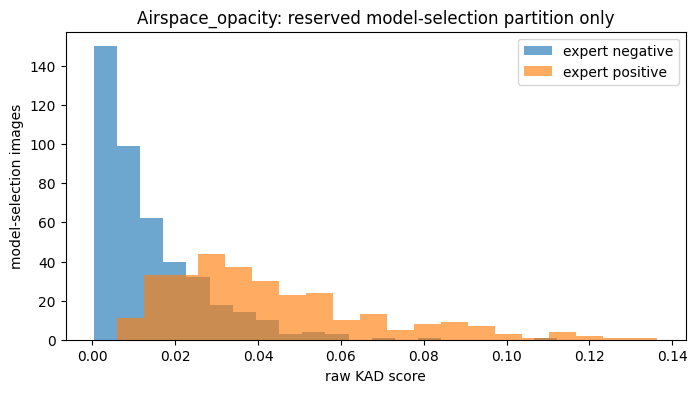

Decision artifact: /content/drive/MyDrive/doctor_assistant/kad_phase1/results/airspace_opacity-818b5f7e9ee6-c667325c2594-20260804T093054015853Z/airspace_opacity_decision.json


In [11]:
DECISION_ARTIFACT = RESULT_DIR / f"{ACTIVE_TARGET.lower()}_decision.json"

if RUN_CALIBRATION:
    run_step([
        sys.executable, "scripts/calibrate_kad_phase1.py",
        "--benchmark", DEVELOPMENT_RESULT,
        "--predictions", DEVELOPMENT_PREDICTIONS,
        "--active-target", ACTIVE_TARGET,
        "--require-deferred-analysis",
        "--sensitivity-target", "0.85",
        "--specificity-floor", "0.60",
        "--min-calibration-positives", "10",
        "--min-calibration-negatives", "20",
        "--min-threshold-positives", "10",
        "--min-threshold-negatives", "20",
        "--model-selection-fraction", str(PATIENT_ROLE_FRACTIONS["model_selection"]),
        "--calibration-fraction", str(PATIENT_ROLE_FRACTIONS["calibration"]),
        "--threshold-fraction", str(PATIENT_ROLE_FRACTIONS["threshold_selection"]),
        "--acceptance-fraction", str(PATIENT_ROLE_FRACTIONS["acceptance"]),
        "--bootstrap-samples", str(BOOTSTRAP_SAMPLES),
        "--seed", str(PATIENT_PARTITION_SEED),
        "--split-attempts", str(PATIENT_SPLIT_ATTEMPTS),
        "--output", DECISION_ARTIFACT,
    ])
    decision = json.loads(DECISION_ARTIFACT.read_text())
    pixel_evidence = decision.get("development_pixel_evidence", {})
    summary = {
        "active_target": decision.get("active_target"),
        "original_nih_pixels": pixel_evidence.get("original_nih_pixels"),
        "acceptance_eligible": pixel_evidence.get("acceptance_eligible"),
        "calibration_complete": decision.get("calibration_complete"),
        "thresholds_complete": decision.get("thresholds_complete"),
        "acceptance_complete": decision.get("acceptance_complete"),
        "accepted_threshold": decision.get("thresholds", {}).get(ACTIVE_TARGET),
        "diagnostic_candidate_threshold": decision.get("candidate_thresholds", {}).get(ACTIVE_TARGET),
        "status": decision.get("status"),
        "reasons": ", ".join(decision.get("diagnostics", {}).get("reasons", [])),
    }
    import numpy as np
    import pandas as pd
    import matplotlib.pyplot as plt
    from IPython.display import display
    ranking = decision["model_selection_ranking"]
    display(pd.DataFrame([ranking]))
    display(pd.DataFrame([summary]))

    selection_ids = set(
        decision["patient_partition"]["partitions"]["model_selection"]["sample_ids"]
    )
    with np.load(DEVELOPMENT_PREDICTIONS, allow_pickle=False) as prediction_file:
        raw_scores = prediction_file["raw_scores"]
        labels = prediction_file["labels"]
        class_names = prediction_file["class_names"].astype(str).tolist()
        sample_ids = prediction_file["sample_ids"].astype(str)
    if class_names != [ACTIVE_TARGET]:
        raise RuntimeError(f"Expected one endpoint score column, got {class_names}")
    if raw_scores.ndim != 2 or labels.shape != raw_scores.shape or raw_scores.shape[1] != 1:
        raise RuntimeError("Predictions are not an endpoint-isolated one-column artifact")
    target_index = 0
    model_selection_mask = np.asarray([value in selection_ids for value in sample_ids])
    adjudicated = labels[:, target_index] >= 0
    shown = model_selection_mask & adjudicated
    plt.figure(figsize=(8, 4))
    plt.hist(raw_scores[shown & (labels[:, target_index] == 0), target_index], bins=20, alpha=0.65, label="expert negative")
    plt.hist(raw_scores[shown & (labels[:, target_index] == 1), target_index], bins=20, alpha=0.65, label="expert positive")
    plt.xlabel("raw KAD score")
    plt.ylabel("model-selection images")
    plt.title(f"{ACTIVE_TARGET}: reserved model-selection partition only")
    plt.legend()
    plt.show()
    print("Decision artifact:", DECISION_ARTIFACT)
else:
    print("Calibration skipped by configuration; no threshold is accepted.")

## Stop here: inspect the development result

The run is complete when this endpoint's singleton query pack, one-column benchmark JSON/NPZ, and decision JSON are present in their endpoint-bound locations. Repeat the complete inference and calibration workflow separately after changing `ACTIVE_TARGET`; image/manifest/checkpoint caches may be reused, but predictions, calibrators, thresholds, decisions, and locks may not.

If `USE_ORIGINAL_NIH_PIXELS` was false, this run used the 320px mirror: it is limited to candidate ranking plus diagnostic calibration and candidate-threshold selection; untouched-acceptance scores are not read, and no test-ready decision can be frozen. If `USE_ORIGINAL_NIH_PIXELS` was true, this run used verified multi-source original NIH pixels and untouched-acceptance scoring was attempted, but a test-ready decision still requires the patient-support minimums (at least 22 positive and 20 negative patients in the untouched-acceptance role) to be met — check `acceptance_complete`/`status`/`reasons` in the decision summary above. For pneumothorax specifically, the current Google development subset has only 43 pneumothorax-positive images from 33 positive patients, so the four-way patient split cannot leave at least 22 positive patients in the untouched acceptance role for the required two-sided 95% Wilson lower-bound claim, independent of pixel provenance. Either provenance ineligibility or inadequate statistical support is sufficient to fail closed.

Before pneumothorax can be accepted, obtain CANDID-PTX through its ethics-training/data-use process and audit performance with and without chest tubes. NIH age, sex, and view-position audits also remain open.

Do **not** change any command to `--cohort test`. A decision must first be frozen from eligible original-pixel NIH development evidence. A later locked-test notebook must then use original NIH test pixels and bind the exact manifest, query pack, prompt set, calibrator, threshold, decision artifact, runtime contract, and image hashes.

In [13]:
assert development["cohort"] == "development"
assert development["inputs"]["image_provenance"]["original_nih_pixels"] == USE_ORIGINAL_NIH_PIXELS
print("DEVELOPMENT RUN COMPLETE — LOCKED TEST INFERENCE WAS NOT RUN")
print("Original NIH pixels used:", USE_ORIGINAL_NIH_PIXELS)
print("Results folder:", RESULT_DIR)
decision = json.loads(DECISION_ARTIFACT.read_text())
print(decision["diagnostics"]["reasons"])


DEVELOPMENT RUN COMPLETE — LOCKED TEST INFERENCE WAS NOT RUN
Original NIH pixels used: True
Results folder: /content/drive/MyDrive/doctor_assistant/kad_phase1/results/airspace_opacity-818b5f7e9ee6-c667325c2594-20260804T093054015853Z
['sensitivity_lower_95_percent_confidence_bound_below_target', 'specificity_lower_95_percent_confidence_bound_below_floor']
